# Objective:
# Perform full analysis on bhavcopy data
# Identify:
# - Top gainers
# - Top losers
# - Volume leaders
# Use pandas, numpy, and visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("../data/bhavcopy.csv")

# clean column names
df.columns = df.columns.str.strip()

df.columns

Index(['SYMBOL', 'SERIES', 'DATE1', 'PREV_CLOSE', 'OPEN_PRICE', 'HIGH_PRICE',
       'LOW_PRICE', 'LAST_PRICE', 'CLOSE_PRICE', 'AVG_PRICE', 'TTL_TRD_QNTY',
       'TURNOVER_LACS', 'NO_OF_TRADES', 'DELIV_QTY', 'DELIV_PER'],
      dtype='object')

In [ ]:
# returns
df["RETURN"] = (df["CLOSE_PRICE"] - df["PREV_CLOSE"]) / df["PREV_CLOSE"] 

# intraday movement
df["INTRADAY"] = df["CLOSE_PRICE"] - df["OPEN_PRICE"]

# range
df["RANGE"] = df["HIGH_PRICE"] - df["LOW_PRICE"]

# numpy return (practice)
close = df["CLOSE_PRICE"].values
np_returns = (close[1:] - close[:-1]) / close[:-1]
np_returns = np.append([np.nan], np_returns)

df["NP_RETURN"] = np_returns

In [13]:
df.head(5)

,SYMBOL,SERIES,DATE1,PREV_CLOSE,OPEN_PRICE,HIGH_PRICE,LOW_PRICE,LAST_PRICE,CLOSE_PRICE,AVG_PRICE,TTL_TRD_QNTY,TURNOVER_LACS,NO_OF_TRADES,DELIV_QTY,DELIV_PER,RETURN,INTRADAY,RANGE,NP_RETURN
0,1018GS2026,GS,22-Apr-2026,102.98,102.79,102.99,102.79,102.99,102.99,102.98,349,0.36,11,349,100.00,0.000097,0.20,0.20,NaN
1,20MICRONS,EQ,22-Apr-2026,177.43,178.14,179.58,177.10,179.24,178.38,178.38,65747,117.28,1374,34726,52.82,0.005354,0.24,2.48,0.732013
2,21STCENMGM,EQ,22-Apr-2026,33.71,34.31,34.38,34.31,34.38,34.38,34.36,4514,1.55,14,4514,100.00,0.019875,0.07,0.07,-0.807265
3,360ONE,EQ,22-Apr-2026,1108.35,1114.00,1123.80,1042.00,1055.00,1054.90,1068.54,5903548,63081.65,127390,2433064,41.21,-0.048225,-59.10,81.80,29.683537
4,3BBLACKBIO,EQ,22-Apr-2026,1388.05,1399.00,1399.00,1341.05,1350.10,1355.15,1368.79,3250,44.49,507,2074,63.82,-0.023702,-43.85,57.95,0.284624


Top gainers

In [14]:
top_gainers = df.sort_values(by="RETURN", ascending=False).head(10)

top_gainers[["SYMBOL", "RETURN"]]

,SYMBOL,RETURN
2525,SDREAMS,0.200000
1383,IRMENERGY,0.200000
1930,NAGREEKCAP,0.199802
686,DANGEE,0.199468
2663,SHYAMTEL,0.199377
192,AMBEY,0.197952
251,ARE&M,0.161411
1603,LAHOTIOV,0.150000
3204,YAAP,0.142225
1295,IITL,0.139786


Top losers

In [15]:
top_losers = df.sort_values(by="RETURN").head(10)

top_losers[["SYMBOL", "RETURN"]]

,SYMBOL,RETURN
2822,SUNREST-RE,-0.125000
1174,HCLTECH,-0.108174
806,EBGNG,-0.099964
1129,GSMFOILS,-0.087628
1697,MADHUSUDAN,-0.075929
2754,SPECTSTM,-0.073790
2879,TARIL,-0.071107
1213,HEXT,-0.069324
1367,INVPRECQ,-0.066955
1759,MASON,-0.062326


In [16]:
volume_leaders = df.sort_values(by="TTL_TRD_QNTY", ascending=False).head(5)

volume_leaders[["SYMBOL", "TTL_TRD_QNTY"]]

,SYMBOL,TTL_TRD_QNTY
1276,IDEA,354014633
1457,JPPOWER,226335685
2849,SUZLON,147736421
2402,RPOWER,130508684
1097,GROWW,122276331


In [18]:
filtered = df[
    (df["TTL_TRD_QNTY"] > 1000000) &
    (df["RETURN"] > 0.02)
]
print(filtered)

          SYMBOL SERIES         DATE1  PREV_CLOSE  OPEN_PRICE  HIGH_PRICE  \
61      AARTIIND     EQ   22-Apr-2026      451.20      450.10      472.60   
67           ABB     EQ   22-Apr-2026     7255.00     7253.00     7822.50   
75         ABLBL     EQ   22-Apr-2026      106.44      107.00      109.55   
93           ACE     EQ   22-Apr-2026      912.80      907.00      954.80   
98     ACMESOLAR     EQ   22-Apr-2026      296.25      299.00      306.90   
...          ...    ...           ...         ...         ...         ...   
3161   WAAREERTL     EQ   22-Apr-2026     1061.40     1061.50     1122.00   
3164  WALCHANNAG     EQ   22-Apr-2026      190.04      190.05      217.75   
3169  WEBELSOLAR     EQ   22-Apr-2026       88.27       93.00       97.09   
3171         WEL     EQ   22-Apr-2026       97.58       99.50      106.73   
3172     WELCORP     EQ   22-Apr-2026     1100.60     1112.00     1151.00   

      LOW_PRICE  LAST_PRICE  CLOSE_PRICE  AVG_PRICE  TTL_TRD_QNTY  \
61    

Top gainers chart

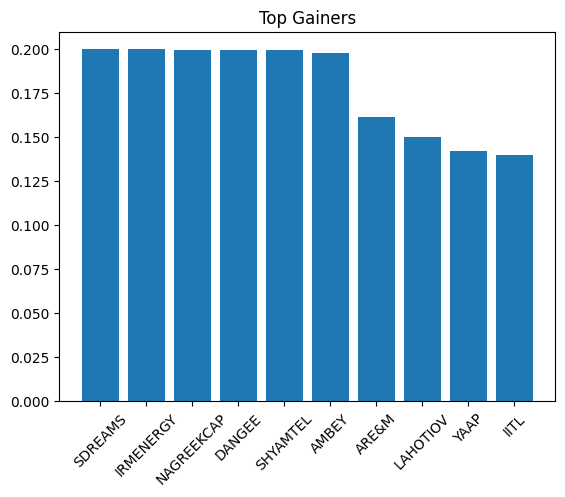

In [19]:
plt.figure()
plt.bar(top_gainers["SYMBOL"], top_gainers["RETURN"])

plt.title("Top Gainers")
plt.xticks(rotation=45)

plt.show()

Volume leaders chart

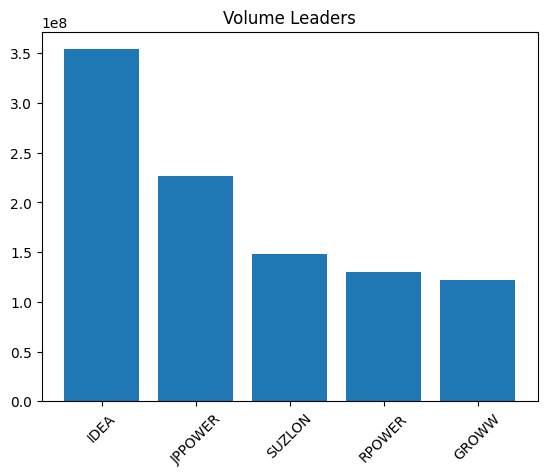

In [20]:
plt.figure()
plt.bar(volume_leaders["SYMBOL"], volume_leaders["TTL_TRD_QNTY"])

plt.title("Volume Leaders")
plt.xticks(rotation=45)

plt.show()

Return distribution

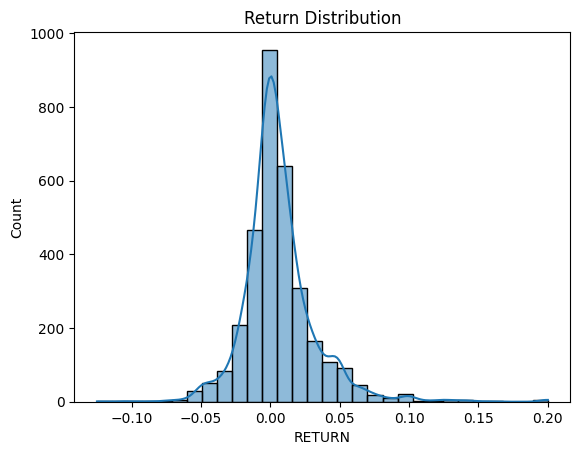

In [22]:
sns.histplot(df["RETURN"].dropna(), bins=30, kde=True)

plt.title("Return Distribution")
plt.show()

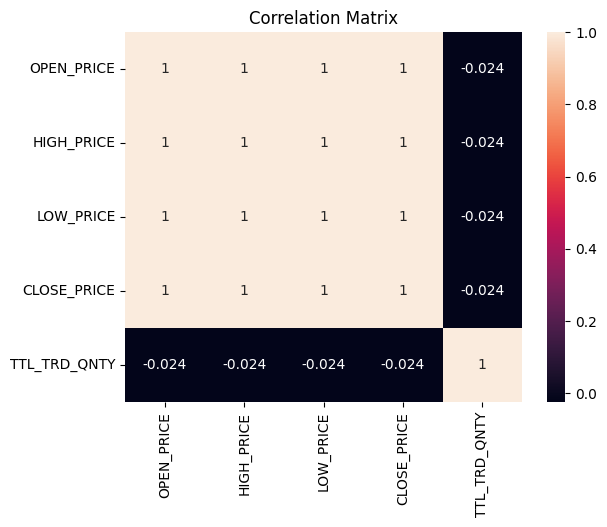

In [23]:
corr = df[[
    "OPEN_PRICE",
    "HIGH_PRICE",
    "LOW_PRICE",
    "CLOSE_PRICE",
    "TTL_TRD_QNTY"
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

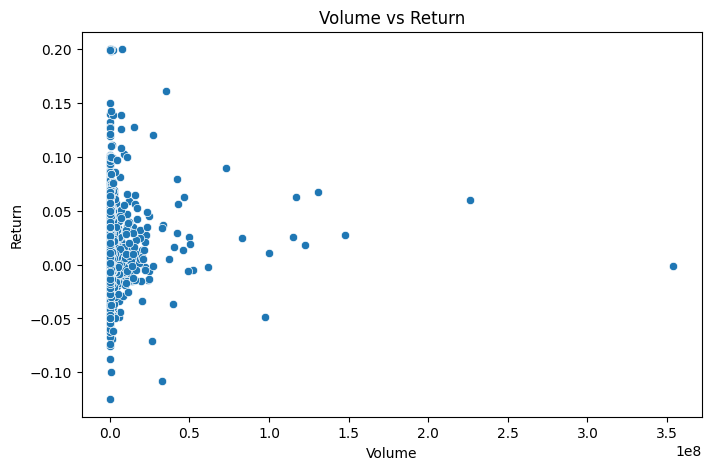

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["TTL_TRD_QNTY"], y=df["RETURN"])

plt.xlabel("Volume")
plt.ylabel("Return")
plt.title("Volume vs Return")

plt.show()

# Insights:
# 1. Top gainers show strong positive return momentum.
# 2. Top losers indicate sharp negative movement.
# 3. High volume stocks often represent institutional activity.
# 4. Price variables (open, high, low, close) are highly correlated.
# 5. Return distribution shows presence of volatility and outliers.